In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme()


In [2]:
df = pd.read_csv("../data/raw/diabetic_data.csv")
df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())


Shape: (101766, 50)

Columns:
 ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
df["readmitted"].value_counts(dropna=False)


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

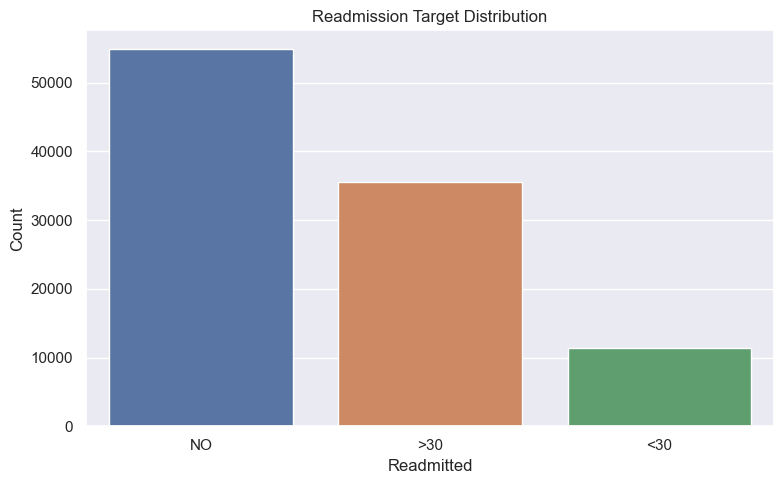

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="readmitted")
plt.title("Readmission Target Distribution")
plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [7]:
#This dataset uses ? instead of normal nulls in many categorical columns.
missing_question = (df == "?").sum().sort_values(ascending=False)
missing_question[missing_question > 0]


weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [8]:
df_eda = df.replace("?", pd.NA)


In [9]:
missing_summary = df_eda.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]


weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

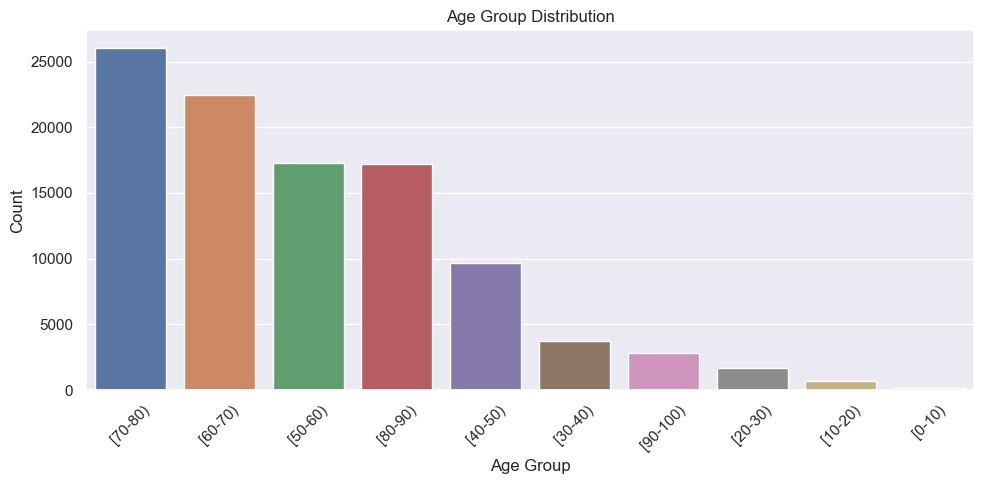

In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_eda, x="age", order=df_eda["age"].value_counts().index)
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


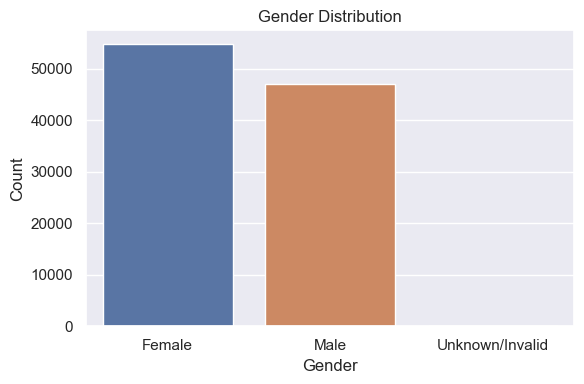

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_eda, x="gender")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


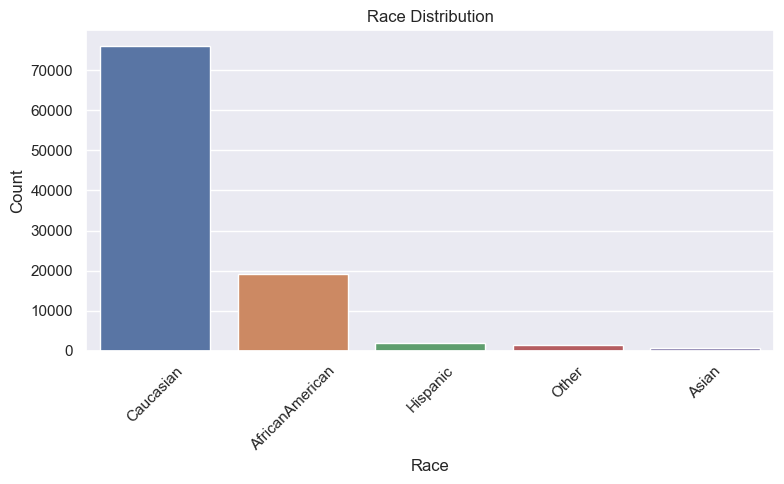

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_eda, x="race", order=df_eda["race"].value_counts().index)
plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


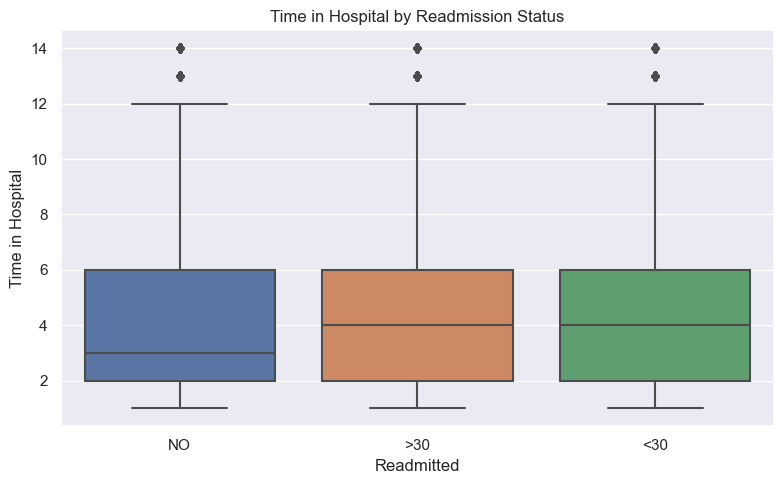

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x="readmitted", y="time_in_hospital")
plt.title("Time in Hospital by Readmission Status")
plt.xlabel("Readmitted")
plt.ylabel("Time in Hospital")
plt.tight_layout()
plt.show()


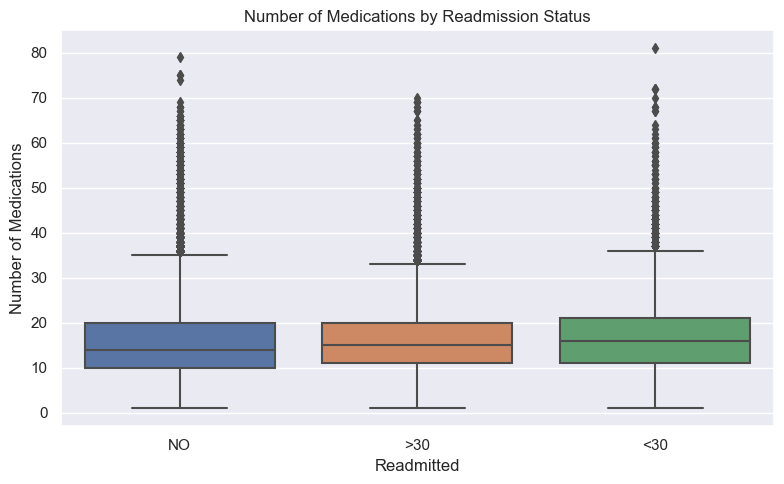

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x="readmitted", y="num_medications")
plt.title("Number of Medications by Readmission Status")
plt.xlabel("Readmitted")
plt.ylabel("Number of Medications")
plt.tight_layout()
plt.show()


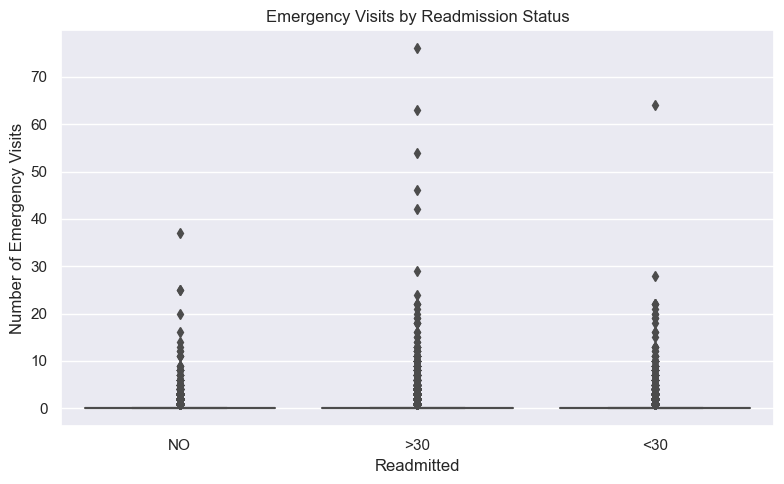

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x="readmitted", y="number_emergency")
plt.title("Emergency Visits by Readmission Status")
plt.xlabel("Readmitted")
plt.ylabel("Number of Emergency Visits")
plt.tight_layout()
plt.show()


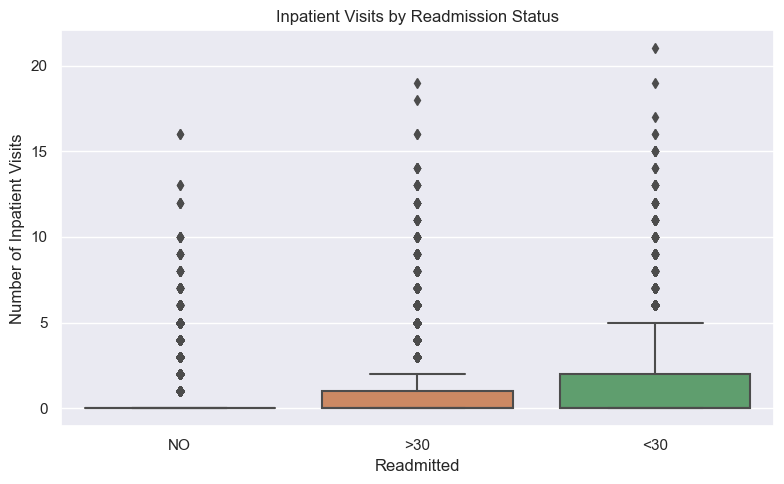

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x="readmitted", y="number_inpatient")
plt.title("Inpatient Visits by Readmission Status")
plt.xlabel("Readmitted")
plt.ylabel("Number of Inpatient Visits")
plt.tight_layout()
plt.show()


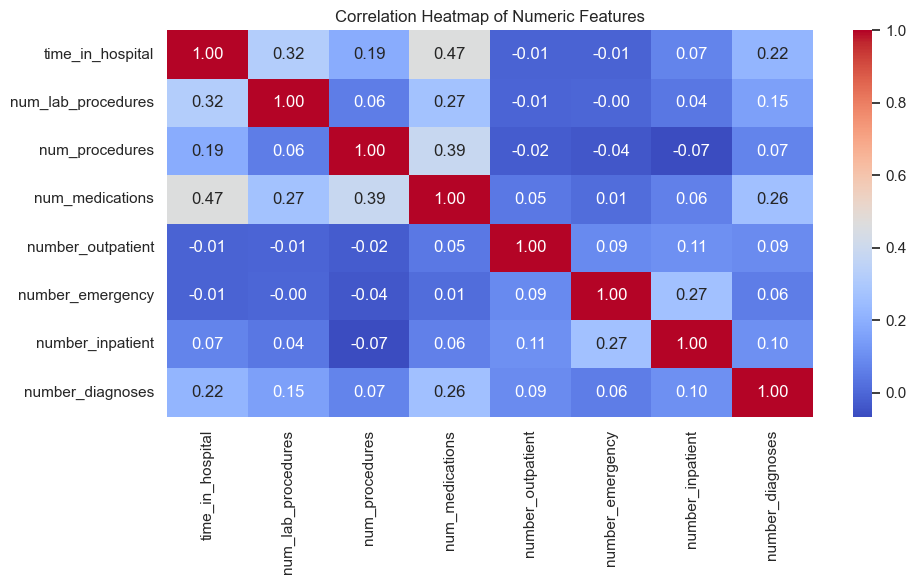

In [17]:
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

corr_df = df_eda[numeric_cols].copy()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


### Key EDA observations

- The target is imbalanced, with far fewer `<30` readmissions than `NO` or `>30`.
- Several columns contain missing values represented by `?`.
- Older age groups appear frequently in the dataset.
- Patients with more inpatient or emergency visits tend to show higher readmission risk.
- Longer hospital stays and higher medication counts may also be associated with readmission.
